Vetorizando com foco em pronomes e expressões...
Balanceando as categorias de texto via SMOTE...
Treinando XGBoost Final (isso pode demorar alguns minutos)...

=== RELATÓRIO DE CLASSIFICAÇÃO NLP (FINAL OTIMIZADO) ===
               precision    recall  f1-score   support

         ADHD       0.89      0.85      0.87       401
      Anxiety       0.75      0.71      0.73       384
       Autism       0.77      0.80      0.79       299
          BPD       0.81      0.81      0.81       324
      Bipolar       0.79      0.72      0.75       365
   Depression       0.57      0.67      0.62       287
schizophrenia       0.57      0.62      0.59       195

     accuracy                           0.75      2255
    macro avg       0.74      0.74      0.74      2255
 weighted avg       0.76      0.75      0.75      2255


✅ Modelos salvos com sucesso na pasta /src/!


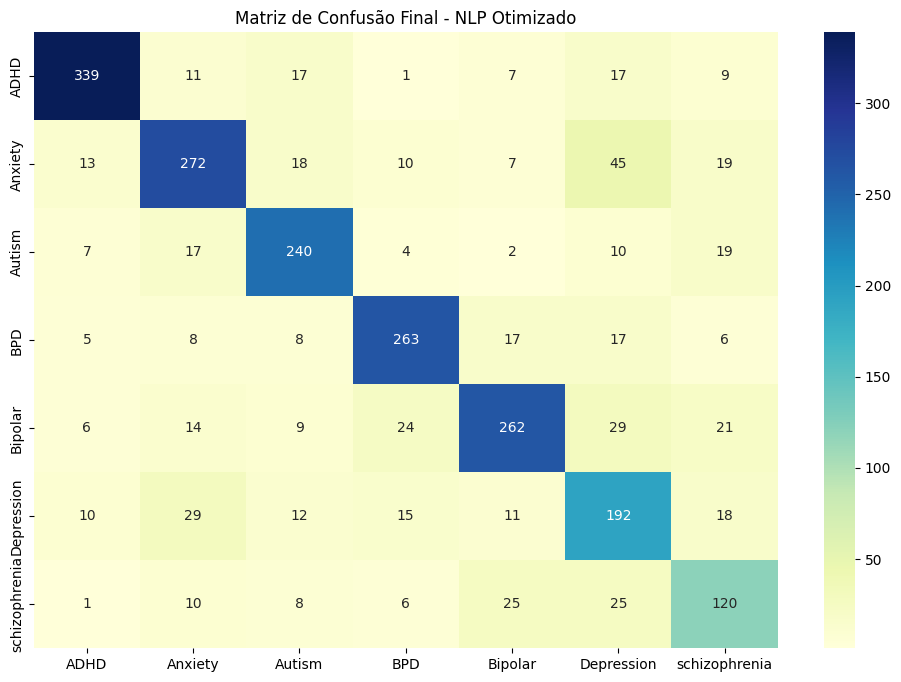


Teste Prático:
Texto: I've been feeling very anxious and my heart is always racing when I think about work.
Predição: Anxiety (73.04% de confiança)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE  # IMPORTAÇÃO QUE FALTOU
import joblib

# 1. Carga e Limpeza
df_text = pd.read_csv('../data/Mental Health Disorder Detection Dataset.csv')
df_text = df_text.dropna(subset=['body', 'category'])

# 2. Preparação do Alvo
le_nlp = LabelEncoder()
y = le_nlp.fit_transform(df_text['category'])
target_names = le_nlp.classes_

# 3. Divisão Estratificada
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    df_text['body'], y, test_size=0.2, random_state=42, stratify=y
)

# 4. TF-IDF com Ajuste Psicológico (Mantendo pronomes)
print("Vetorizando com foco em pronomes e expressões...")
vectorizer = TfidfVectorizer(
    max_features=5000, 
    ngram_range=(1, 2),
    min_df=5
)

X_train_vec = vectorizer.fit_transform(X_train_t)
X_test_vec = vectorizer.transform(X_test_t)

# 5. Balanceamento (SMOTE)
print("Balanceando as categorias de texto via SMOTE...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_vec, y_train_t)

# 6. Modelo XGBoost Final
print("Treinando XGBoost Final (isso pode demorar alguns minutos)...")
modelo_nlp_final = XGBClassifier(
    n_estimators=250, 
    learning_rate=0.05, 
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)
modelo_nlp_final.fit(X_train_res, y_train_res)

# 7. Predição e Avaliação
y_pred_t = modelo_nlp_final.predict(X_test_vec)

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO NLP (FINAL OTIMIZADO) ===")
print(classification_report(y_test_t, y_pred_t, target_names=target_names))

# 8. Salvando os arquivos definitivos
joblib.dump(modelo_nlp_final, '../src/modelo_nlp_final.pkl')
joblib.dump(vectorizer, '../src/vectorizer_nlp.pkl')
joblib.dump(le_nlp, '../src/label_encoder_nlp.pkl')
print("\n✅ Modelos salvos com sucesso na pasta /src/!")

# 9. Matriz de Confusão
plt.figure(figsize=(12,8))
sns.heatmap(confusion_matrix(y_test_t, y_pred_t), annot=True, fmt='d', 
            xticklabels=target_names, yticklabels=target_names, cmap='YlGnBu')
plt.title('Matriz de Confusão Final - NLP Otimizado')
plt.show()

# 10. Função de Teste
def prever_texto(texto):
    vec = vectorizer.transform([texto])
    pred = modelo_nlp_final.predict(vec)[0]
    prob = modelo_nlp_final.predict_proba(vec)[0][pred]
    doenca = le_nlp.inverse_transform([pred])[0]
    return doenca, prob

texto_teste = "I've been feeling very anxious and my heart is always racing when I think about work."
doenca, certeza = prever_texto(texto_teste)
print(f"\nTeste Prático:\nTexto: {texto_teste}\nPredição: {doenca} ({certeza*100:.2f}% de confiança)")